# Data Analysis

## Imports

In [75]:
import os, sys
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.data_analysis_utils import (
    plot_quant_distribution,
    plot_cat_distribution
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

## Head

In [76]:
processed_data.head()

comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca_01,embedding_pca_02,embedding_pca_03,embedding_pca_04,embedding_pca_05,embedding_pca_06,…,embedding_pca_19,embedding_pca_20,embedding_pca_21,embedding_pca_22,embedding_pca_23,embedding_pca_24,embedding_pca_25,embedding_pca_26,embedding_pca_27,embedding_pca_28,embedding_pca_29,embedding_pca_30,embedding_pca_31,embedding_pca_32,embedding_pca_33,embedding_pca_34,embedding_pca_35,embedding_pca_36,embedding_pca_37,embedding_pca_38,embedding_pca_39,embedding_pca_40,embedding_pca_41,embedding_pca_42,embedding_pca_43,embedding_pca_44,embedding_pca_45,embedding_pca_46,embedding_pca_47,embedding_pca_48,embedding_pca_49,embedding_pca_50,political_stance_score_label,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label
str,str,str,i64,f64,"datetime[μs, UTC]",str,str,str,i64,f64,i64,f64,"datetime[μs, UTC]",str,str,str,"datetime[μs, UTC]",str,i64,str,i64,str,i64,str,i64,str,i64,str,f64,str,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str
"""oc4zaua""","""1s1mro9""","""Israel has all the conditions …",-6,1.7743e9,2026-03-24 02:49:52 UTC,"""IsraelPalestine""","""AMA: I am an american Zionist …","""Like basically every American …",78,0.78,438,1.7743e9,2026-03-23 17:05:40 UTC,"""https://www.reddit.com/r/Israe…","""Conflict/Security""","""new""",2026-03-26 10:09:05.123482 UTC,"""Post Title: AMA: I am an amer…",5,"""The comment explicitly discuss…",2,"""The text presents a clear posi…",3,"""The comment expresses a strong…",7,"""The comment frames Israel's ac…",1,"""The comment expresses a strong…",-0.5,"""The comment expresses a strong…",-0.297722,-0.037968,0.15043,-0.043519,-0.107923,0.039497,…,0.015923,-0.046658,-0.019419,-0.033848,0.026682,0.079199,-0.019172,0.005173,-0.051788,-0.04431,-0.011724,0.060304,-0.015806,0.070142,-0.069514,0.075253,0.02668,-0.047792,0.042678,-0.047576,-0.020191,-0.022675,-0.00566,-0.004315,0.033596,-0.047218,-0.018325,0.019351,0.016403,-0.014801,0.006525,0.022762,"""Strongly Pro-Palestine""","""Hostile""","""Ideological""","""Bare Opinion""","""Moderately Negative"""
"""o4iqc6q""","""1r0jp4n""","""It's how the home was created …",0,1.7707e9,2026-02-09 23:15:42 UTC,"""IsraelPalestine""","""I hate how zionism has been tu…","""We always see people talking a…",86,0.73,702,1.7707e9,2026-02-09 23:03:28 UTC,"""https://www.reddit.com/r/Israe…","""Conflict/Security""","""new""",2026-03-26 10:09:05.123482 UTC,"""Post Title: I hate how zionis…",5,"""The comment explicitly discuss…",3,"""The text presents a series of …",3,"""The comment employs a critical…",7,"""The comment critiques the acti…",1,"""The comment strongly criticize…",-0.6,"""The comment expresses a strong…",-0.259118,-0.037505,-0.028814,0.089776,-0.160577,0.064377,…,-0.027238,-0.029471,-0.001694,-0.019725,-0.053957,0.119283,-0.001607,-0.083355,-0.060329,-0.01349,-0.024489,-0.020238,0.113416,0.039364,-0.028712,0.058045,0.02418,0.049666,0.01224,0.079067,-0.048644,0.081777,-0.014991,0.024287,0.013493,-0.081054,0.015737,-0.048204,-0.025401,0.006739,0.054588,-0.006556,"""Strongly Pro-Palestine""","""Hostile""","""Ideological""","""Justified Opinion""","""Moderately Negative"""
"""nh0pm9f""","""1nu6tlp""","""To me, the main problem with t…",11,1.7592e9,2025-09-30 15:10:52 UTC,"""Palestine""","""What’s i

## Describe

In [77]:
processed_data.shape

(76816, 86)

In [78]:
processed_data.describe()

statistic,comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca_01,embedding_pca_02,embedding_pca_03,embedding_pca_04,embedding_pca_05,…,embedding_pca_19,embedding_pca_20,embedding_pca_21,embedding_pca_22,embedding_pca_23,embedding_pca_24,embedding_pca_25,embedding_pca_26,embedding_pca_27,embedding_pca_28,embedding_pca_29,embedding_pca_30,embedding_pca_31,embedding_pca_32,embedding_pca_33,embedding_pca_34,embedding_pca_35,embedding_pca_36,embedding_pca_37,embedding_pca_38,embedding_pca_39,embedding_pca_40,embedding_pca_41,embedding_pca_42,embedding_pca_43,embedding_pca_44,embedding_pca_45,embedding_pca_46,embedding_pca_47,embedding_pca_48,embedding_pca_49,embedding_pca_50,political_stance_score_label,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label
str,str,str,str,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str
"""count""","""76816""","""76816""","""76816""",76816.0,76816.0,"""76816""","""76816""","""76816""","""76816""",76816.0,76816.0,76816.0,76816.0,"""76816""","""76816""","""76816""","""76816""","""76816""","""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76771""",76816.0,76816.0,76816.0,76816.0,76816.0,…,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,"""76816""","""76816""","""76816""","""76816""","""76816"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""45""",0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0"""
"""mean""",null,null,null,19.580257,1.7578e9,"""2025-09-13 19:59:30.968417+00:…",null,null,null,891.679624,0.834575,239.965541,1.7577e9,"""2025-09-12 15:04:52.787010+00:…",null,null,null,"""2026-03-26 10:09:05.123482+00:…",null,4.371459,null,1.829684,null,2.506262,null,4.825518,null,2.866968,null,-0.375026,null,-0.001807,0.00067,-0.004456,0.001133,-0.004076,…,-0.000037,-0.000087,0.000651,0.000923,0.000053,0.000326,0.000514,0.000379,-0.001118,-0.000515,-0.000595,0.000195,0.000167,0.000843,0.000139,0.001042,0.000154,0.000146,0.000376,0.000029,0.000714,-0.000268,0.00023,-0.000467,-0.000604,0.000226,-0.000333,-0.000359,0.000058,-0.000178,0.000271,-0.000176,null,null,null,null,null
"""std""",null,null,null,99.374435,8.4015e6,null,null,null,null,1811.162709,0.169594,425.445408,8.4216e6,null,null,null,null,null,null,0.483198,null,0.993416,null,1.291982,null,2.458282,null,1.52992,null,0.370529,null,0.184107,0.152562,0.125214,0.113788,0.105522,…,0.065163,0.064713,0.06369,0.062561,0.061492,0.059927,0.059598,0.058242,0.056276,0.056586,0.054925,0.054872,0.054188,0.05249,0.05274,0.051343,0.051168,0.049547,0.049115,0.049221,0.048485,0.048227,0.047707,0.047192,0.046891,0.046119,0.045945,0.045141,0.044746,0.044343,0.04379,0.04385

In [79]:
processed_data.columns

['comment_id',
 'post_id',
 'comment_body',
 'comment_score',
 'comment_created_utc',
 'comment_created_date',
 'post_subreddit',
 'post_title',
 'post_body',
 'post_score',
 'post_upvote_ratio',
 'post_num_comments',
 'post_created_utc',
 'post_created_date',
 'post_url',
 'extraction_query',
 'extraction_sort',
 'extraction_time',
 'text_content',
 'content_relevance_score',
 'reasoning_content_relevance_score',
 'argument_quality_score',
 'reasoning_argument_quality_score',
 'discourse_tone_score',
 'reasoning_discourse_tone_score',
 'dominant_frame_score',
 'reasoning_dominant_frame_score',
 'political_stance_score',
 'reasoning_political_stance_score',
 'sentiment_score',
 'reasoning_sentiment_score',
 'embedding_pca_01',
 'embedding_pca_02',
 'embedding_pca_03',
 'embedding_pca_04',
 'embedding_pca_05',
 'embedding_pca_06',
 'embedding_pca_07',
 'embedding_pca_08',
 'embedding_pca_09',
 'embedding_pca_10',
 'embedding_pca_11',
 'embedding_pca_12',
 'embedding_pca_13',
 'embedding

## Visualization

### Time Variables

In [80]:
date_cols = [
    "post_created_date", 
    "comment_created_date"
]

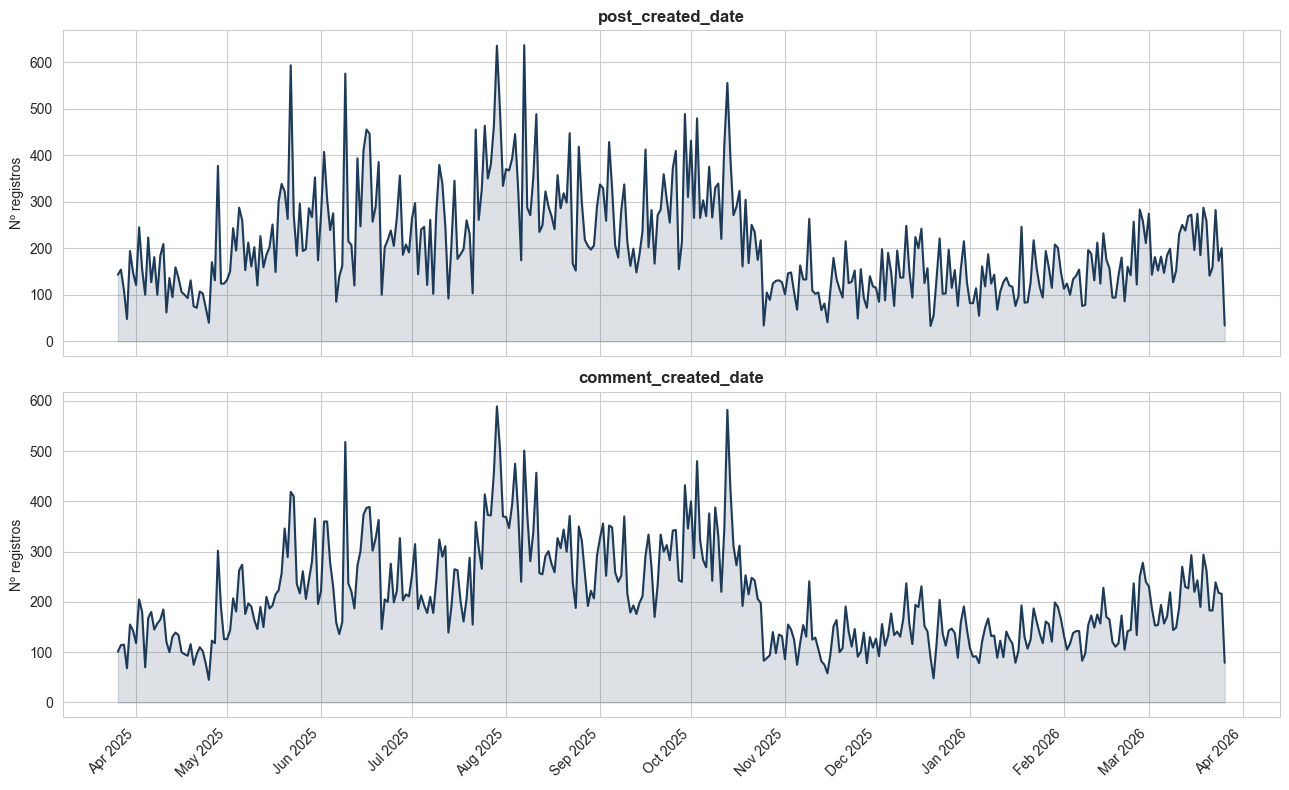

In [81]:
fig, axes = plt.subplots(len(date_cols), 1, figsize=(13, 4 * len(date_cols)), sharex=True)

for ax, col in zip(axes, date_cols):
    daily = (
        processed_data
        .with_columns(pl.col(col).dt.truncate("1d").alias("day"))
        .group_by("day")
        .agg(pl.len().alias("count"))
        .sort("day")
    )

    days   = daily["day"].to_list()
    counts = daily["count"].to_list()

    ax.plot(days, counts, color="#1C3B5A", linewidth=1.5)
    ax.fill_between(days, counts, alpha=0.15, color="#1C3B5A")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Nº registros")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [82]:
processed_data['extraction_time'].unique()

extraction_time
"datetime[μs, UTC]"
2026-03-26 10:09:05.123482 UTC


### Query variables

In [83]:
query_cols = [
    'extraction_query',
    'extraction_sort',
    'post_subreddit'
]

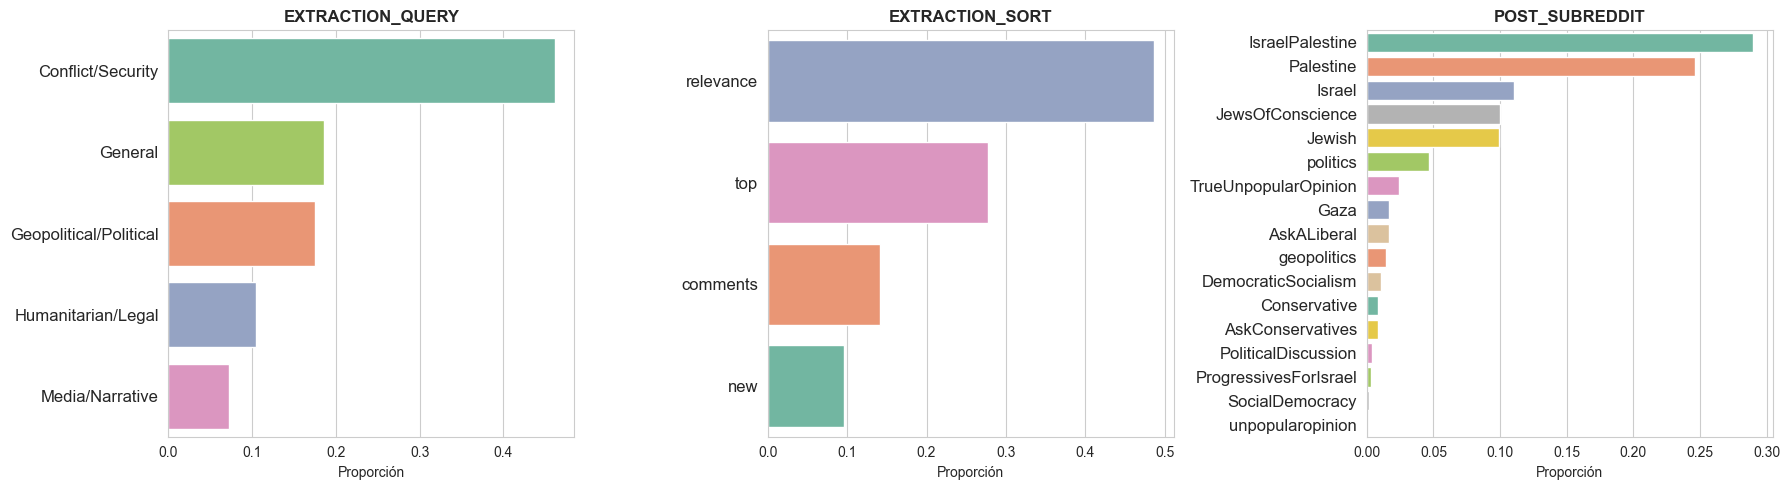

In [84]:
plot_cat_distribution(
    df = processed_data,
    cat_cols = query_cols,
    x_rotation = 90,
    order=True,
    orient="h", 
    max_cols=3
)

### Reddit Scores

In [85]:
reddit_scores = [
    'post_score',
    'post_upvote_ratio',
    'post_num_comments',
    'comment_score'
]

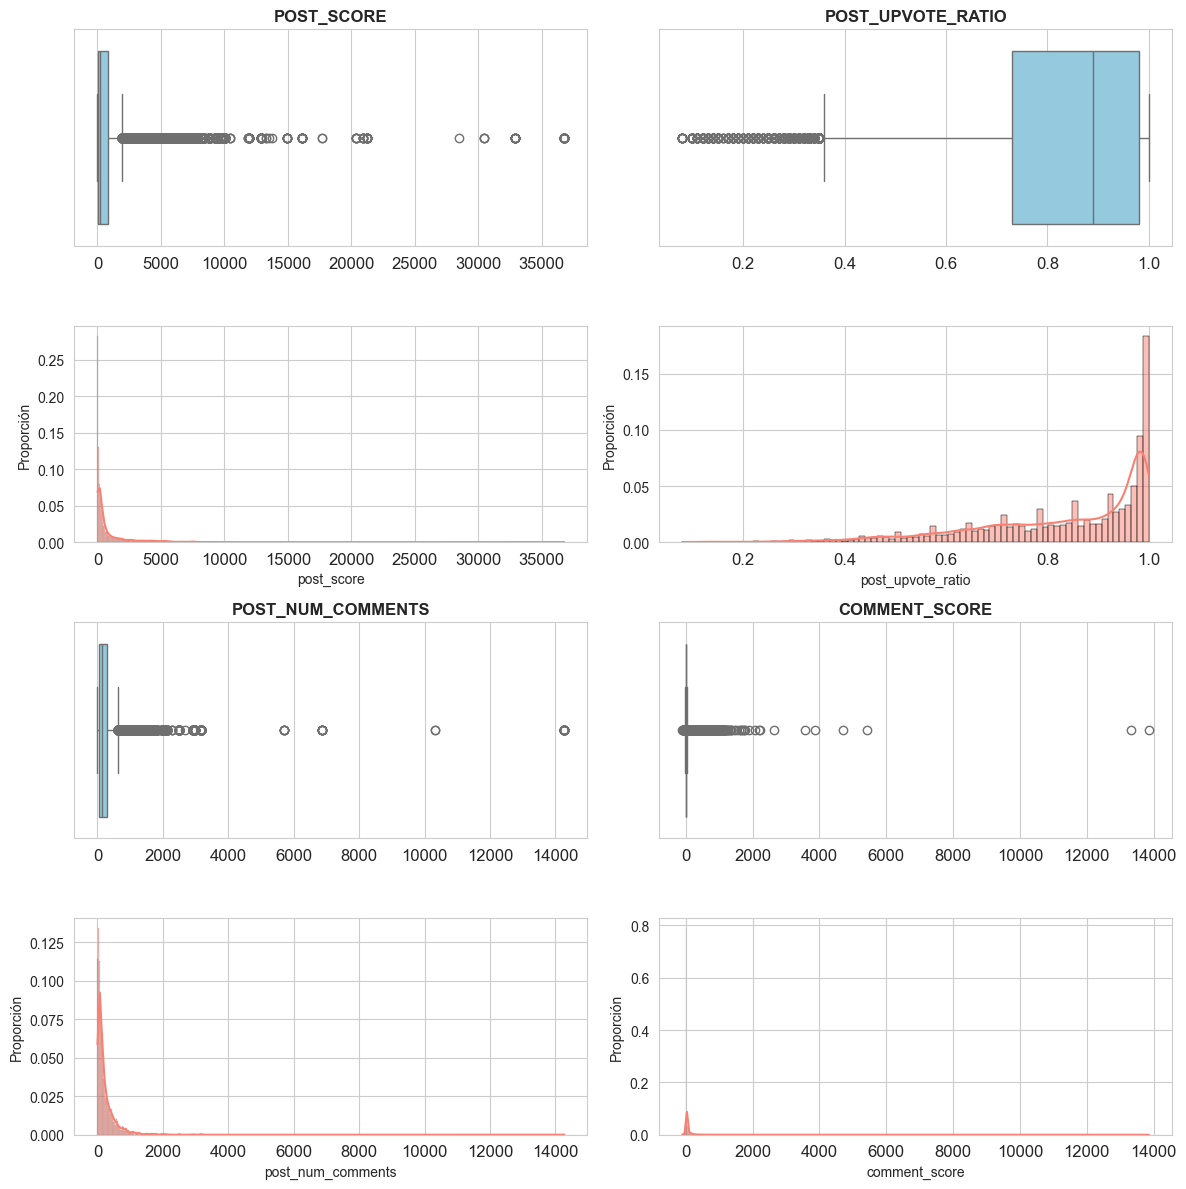

In [86]:
plot_quant_distribution(
    df = processed_data,
    quant_cols = reddit_scores,
    max_cols=2
)

### Discursive Scores

In [96]:
discursive_quant_scores = [
    'argument_quality_score',
    'political_stance_score',
    'sentiment_score'
]

discursive_cat_scores = [
    'content_relevance_score',
    'discourse_tone_score_label',
    'dominant_frame_score_label',
    'argument_quality_score_label',
    'sentiment_score_label',
    'political_stance_score_label'
]

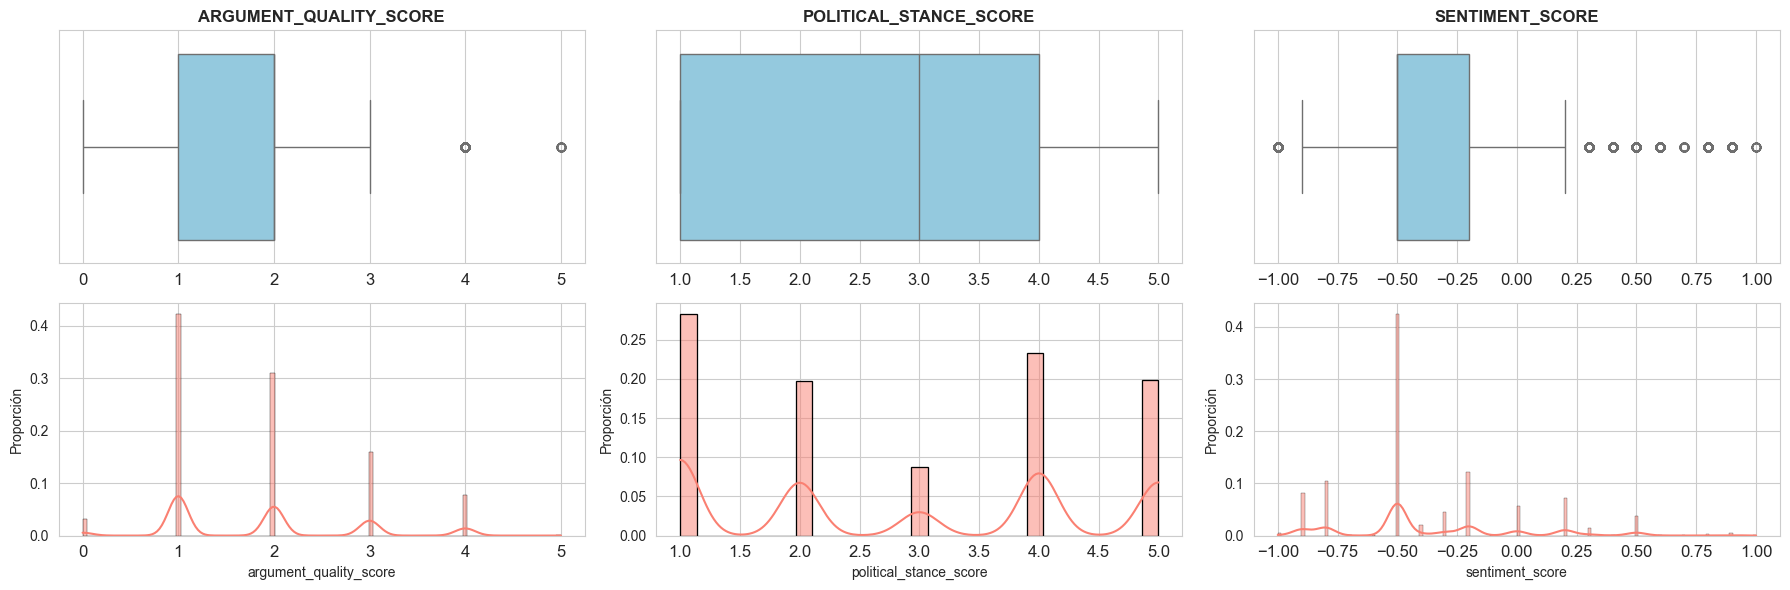

In [88]:
plot_quant_distribution(
    df = processed_data,
    quant_cols = discursive_quant_scores,
    max_cols=3
)

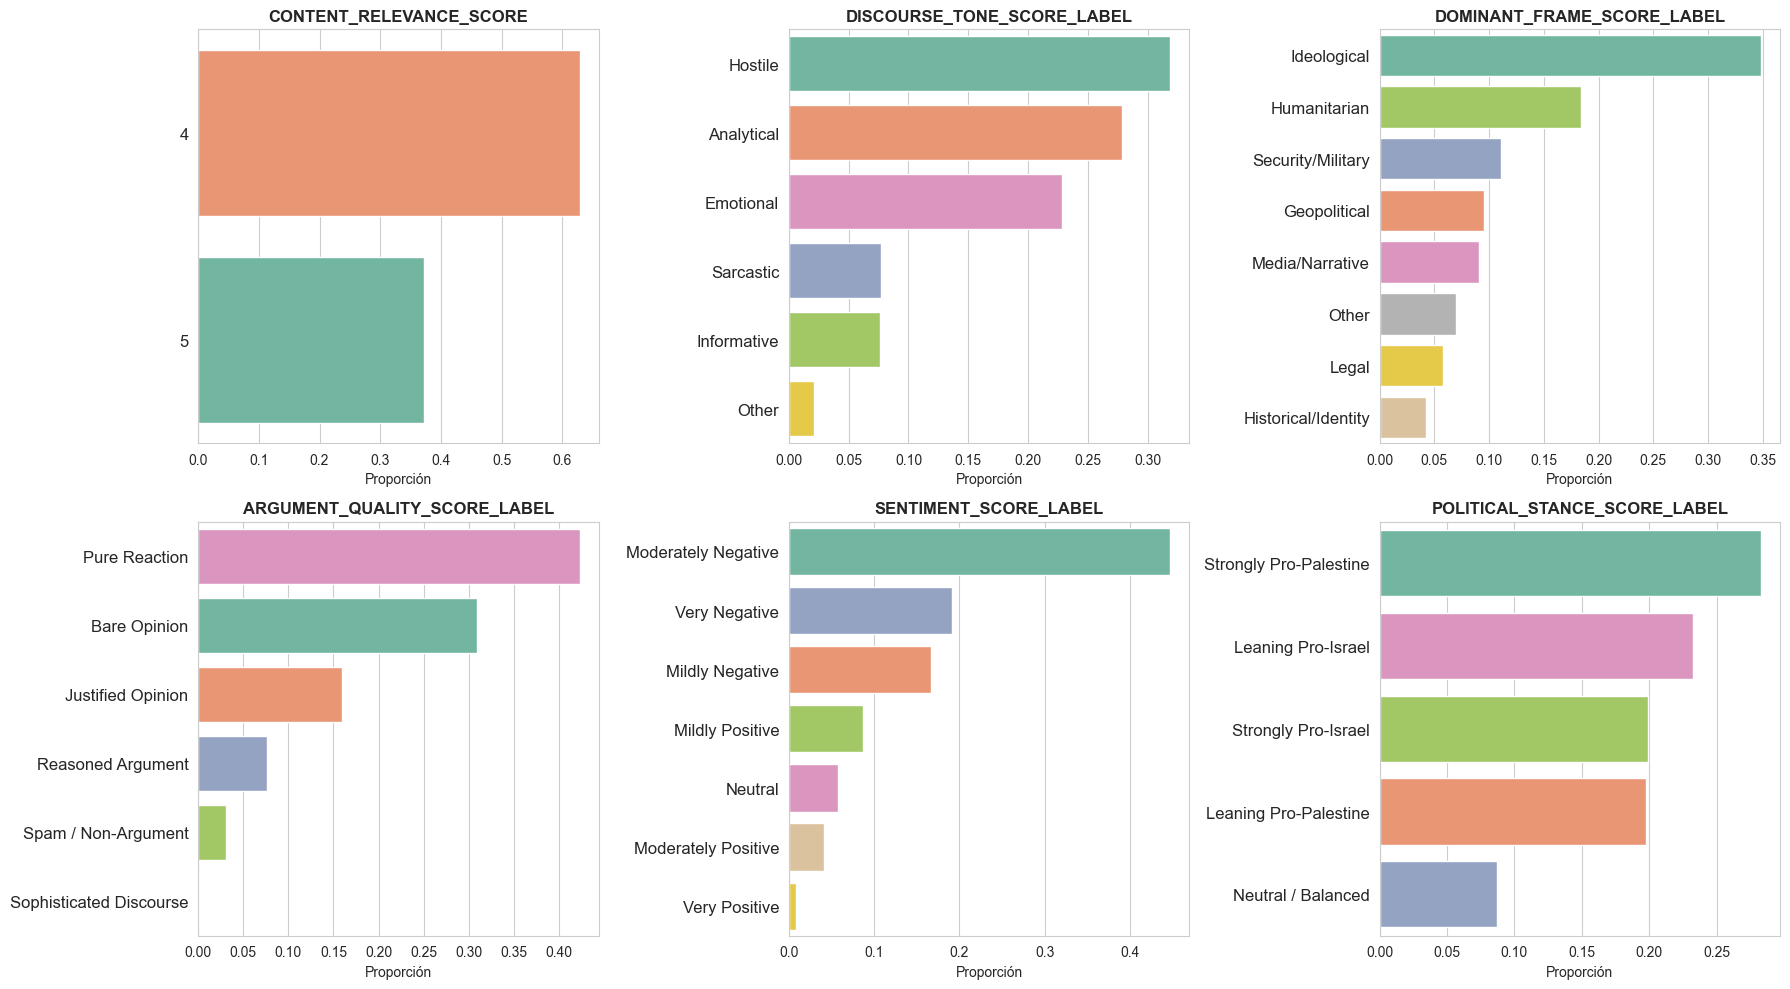

: 

In [ ]:
plot_cat_distribution(
    df = processed_data,
    cat_cols = discursive_cat_scores,
    x_rotation = 90,
    order=True,
    orient="h", 
    max_cols=3
)